# PR03 · Read a deformation field and detect folding

<!-- paper-first -->
### Research question

**Reading:** [PP04](../../curriculum/papers/processing.md#pp04). Review the assigned figure or result before starting the lesson.

**Question:** Can an image look aligned while its deformation is anatomically implausible?

Record a prediction, a source location, and one point you want this lesson to clarify. Ask your AI tutor to distinguish the paper’s evidence from its interpretation.
<!-- /paper-first -->

**Format:** 75–100 minutes for this lesson and its small executable lab, followed by the explicitly labeled upstream practice. Run this notebook from a fresh kernel, top to bottom. Core data are synthetic. Software: NumPy, SciPy, Matplotlib; extra imports are stated in code. This is one stage of a longer processing course, not a replacement for supervised research training.

## Learning objectives

- Interpret spatially varying displacements and local expansion.
- Distinguish a genuine inverse from negating a displacement field.
- Explain why numerical similarity cannot validate a nonlinear warp.

## Understand the operation

An affine mapping has the same linear action everywhere. A nonlinear deformation allows displacement to vary with location, so one neighborhood can expand while another contracts. This flexibility helps align brains with different shapes but also creates opportunities for implausible matches. Regularization discourages extreme changes; its form is part of the method, not an optional cosmetic setting.

The Jacobian describes local changes in coordinates. In one dimension it is the derivative of the mapping. In three dimensions it is a matrix of partial derivatives; its determinant describes local volume scaling. For an orientation-preserving diffeomorphism, the determinant stays positive. Nonpositive values can reveal folds or singularities. Positive values alone are not a complete anatomical validation, and a globally orientation-reversing affine has a different interpretation from a local fold.

An inverse deformation must be evaluated at corresponding locations. If `phi(x)=x+u(x)`, its inverse is not generally `y-u(y)`, because the displacement at `y` is not the displacement at the original `x`. Our one-dimensional example makes this visible using an invertible sinusoidal warp, an approximate inverse from a sampled lookup, and a deliberately folded warp. This teaches transform semantics without pretending to implement ANTs or FNIRT optimization. Real displacement files add units, coordinate conventions and representation choices such as absolute versus relative fields. Those conventions have to be read from the actual tool.

## Transformation contract

**Input:** coordinates and a displacement function in matching units. **Output:** warped locations, a sampled inverse, and Jacobian values. **Preserved:** ordering under the monotone warp. **Changed:** local distances and volume elements. **Failure check:** a fold destroys one-to-one correspondence; no unique inverse exists there.


## Read the actual course material

- [Oxford FSL: Registration practical](https://pages.fmrib.ox.ac.uk/fslcourse/practicals/registration/index.html). Public university practical; linked only, no redistribution license assumed.
- [DartBrains: Preprocessing, Image Transformations and Cost Functions](https://github.com/ljchang/dartbrains/blob/5d727f7a72a7f20bfb32603cac8509d78b9647f2/content/Preprocessing.py). CC BY-SA 4.0; linked pinned course chapter.

Read the named topic alongside this lesson; compare its real-image assumptions with our controlled example. These notebooks use original explanations and original code, not copied upstream passages. The source chapter is the place to continue to a complete real-tool practical. External software and downloaded datasets are not silently run by this notebook.


## Predict, then ask your AI assistant

Use Goose with your installed Ollama model, or ChatGPT. The model is a tutor and code author; the local Python runtime performs these calculations. Paste:

> Explain which axis each displacement is defined on. Construct and check an inverse by coordinate correspondence. Compare it with subtracting the displacement evaluated at the destination. Identify where the folded mapping ceases to be one-to-one. Return at most 20 executable lines per cell, show units and array shapes, and preserve the original. Explain the prediction before running. If an assertion fails, diagnose the disagreement rather than deleting the check.

Write your prediction before executing the reference cells below.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(0,100,1001)
def displacement(v,amplitude=8): return amplitude*np.sin(2*np.pi*v/100)
phi = x+displacement(x)
jacobian = np.gradient(phi,x)
inverse_on_grid = np.interp(x,phi,x)
recovered = np.interp(phi,x,inverse_on_grid)
bad_recovered = phi-displacement(phi)
folded = x+displacement(x,amplitude=20)
fold_jacobian = np.gradient(folded,x)
print('min Jacobians:',jacobian.min(),fold_jacobian.min())
print('inverse vs negation max errors:',np.max(abs(recovered-x)),np.max(abs(bad_recovered-x)))
assert jacobian.min()>0 and fold_jacobian.min()<0
assert np.max(abs(recovered-x))<.002
assert np.max(abs(bad_recovered-x))>1


min Jacobians: 0.4973484827552852 -0.256628793111787
inverse vs negation max errors: 0.00013454712976823657 2.3891870007673646


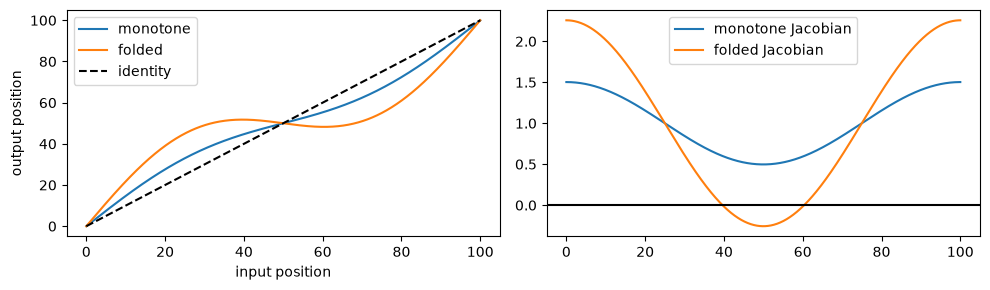

In [2]:
fig,axes = plt.subplots(1,2,figsize=(10,3))
axes[0].plot(x,phi,label='monotone'); axes[0].plot(x,folded,label='folded')
axes[0].plot(x,x,'k--',label='identity'); axes[0].legend()
axes[0].set(xlabel='input position',ylabel='output position')
axes[1].plot(x,jacobian,label='monotone Jacobian')
axes[1].plot(x,fold_jacobian,label='folded Jacobian')
axes[1].axhline(0,color='black'); axes[1].legend()
plt.tight_layout(); plt.show()


## Check and explain

The gentle warp has positive derivatives everywhere and a small interpolation-only round-trip error below .002 coordinate units. Negating at the wrong locations leaves error greater than one unit. The larger-amplitude warp has a negative minimum derivative, so sorting its outputs would hide a meaningful failure.

## Deliberately wrong method

Do not repair the folded example by sorting values or clipping the Jacobian to positive values: neither repairs the estimated anatomical correspondence. Those actions would merely conceal evidence. A successful file save or a smooth displacement plot is not sufficient.

## Transfer to an actual dataset or tool — guided assignment

In Oxford Registration, inspect the supplied nonlinear warp and inverse with the documented tools. Record field representation, transform order and image grid. Compare a forward/inverse round trip on landmarks and an image, allowing for interpolation loss. Add Jacobian and anatomical-boundary inspections. A lesion or missing field of view needs explicit treatment rather than forcing normal anatomy into an absent region. This is a guided real-tool assignment, not an executed ANTs/FNIRT result.

**Submit:** a transformation card, one labeled figure or numerical result, the failed-method diagnosis, and the upstream-practice evidence. If the external exercise has not been run, mark it **not executed** and state the missing software/data; do not convert a proposed command into a claimed result.

## Exit questions and answer key

1. Why is the inverse not generally minus the displacement? **Answer:** the functions are evaluated in different coordinate domains.
2. What does a positive Jacobian prove? **Answer:** a necessary local property for the intended orientation-preserving mapping, not correct anatomy or good registration.


### Return to the research question

Revisit [PP04](../../curriculum/papers/processing.md#pp04) and your initial prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure or section locator. Which part of the published result remains open after this exercise?
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Include this entry in the A2 portfolio when relevant.
